In [1]:
import numpy as np
from cq.numeric import *

D = 3
n = 10000

v, w = rand_ortho_pair(D+1, n)
T = hermfkin(v) + hermfkin(w)
rho = states_to_density(v, w)
g = rho_to_g(rho)

In [2]:
from sklearn.model_selection import train_test_split

X = np.column_stack([g[:,1:], T]) #remove g_0 to avoid bias ruining implicit polynomial fit
X_train, X_test = train_test_split(X, test_size=0.3)

In [3]:
import warnings

N = 6
print('    ' + '   '.join(f'    {i}    ' for i in range(N)))
with warnings.catch_warnings(action="ignore"):
    for deg in range(N):
        print(deg, end='   ')
        for degl in range(deg+1):
            pows = powers(X.shape[1], deg, degl, False)
            f, p = ImplicitPolynomial.fit(X_train, pows)
            #unique fit or multiple converging fits
            s = f'{len(p):3}' if f or not f and len(p)>1 else '  0'
            s += ' | '
            
            pows = powers(X.shape[1], deg, degl, True)
            f, p = ImplicitPolynomial.fit(X_train, pows)
            s += f'{len(p):3}' if f or not f and len(p)>1 else '  0'
            
            print(s, end='   ')
        print()

        0           1           2           3           4           5    
0     0 |   0   
1     0 |   0     0 |   0   
2     0 |   0     0 |   0     0 |   0   
3     0 |   0     0 |   0     1 |   0     1 |   1   
4     0 |   0     4 |   0    20 |   4    26 |  20    27 |  27   
5     1 |   0    47 |   1   117 |  47   145 | 118   152 | 146   153 | 153   


## 3 / 2

In [4]:
pows = powers(X.shape[1], 3, 2, False)
_, p = ImplicitPolynomial.fit(X_train, pows)
p = p[0]
assert np.isclose(np.std(p(X_test)), 0)

In [5]:
import sympy as sp

syms = sp.symbols('g1:7 T') #g1 g2 g3 g4 g5 g6 T
poly = p.to_sympy(*syms, trim=True)
poly

Poly(-0.00334425770174925*g1**3 + 0.0116049436615197*g1**2*g3 - 0.00854805177945193*g1**2*g5 - 0.0342786414413873*g1*g2**2 + 0.0946095961285162*g1*g2*g4 - 0.074028299937069*g1*g2*g6 + 0.0567539351712972*g1*g2*T - 0.120602112239075*g1*g2 - 0.0117049019558676*g1*g3**2 + 0.0164515726213651*g1*g3*g5 - 0.0535081232254942*g1*g4**2 + 0.0537306111838777*g1*g4*g6 + 0.0163834498752243*g1*g4*T - 0.0300363247712716*g1*g4 - 0.00535081232260741*g1*g5**2 + 0.00535081232269032*g1*g6**2 - 0.0897358506611089*g1*g6*T + 0.20639245651998*g1*g6 + 0.0601966386285812*g1*T**2 - 0.361179831770719*g1*T + 0.459835433966973*g1 - 0.017066093619229*g2**2*g3 + 0.0433508340234291*g2**2*g5 - 0.00709424189662123*g2*g3*g4 + 0.0582851447266586*g2*g3*g6 - 0.110056060802157*g2*g3*T + 0.269347727752539*g2*g3 - 0.0528773570979279*g2*g4*g5 - 0.0320514141986635*g2*g5*g6 + 0.139884347344002*g2*g5*T - 0.316898490587784*g2*g5 + 0.00341321872393011*g3**3 - 0.00732690152517728*g3**2*g5 + 0.0163834498745813*g3*g4**2 - 0.0388855352861

In [6]:
poly = sp.Poly(poly, syms[-1])
poly

Poly((0.0601966386285812*g1 - 0.0879228183000805*g5)*T**2 + (0.0567539351712972*g1*g2 + 0.0163834498752243*g1*g4 - 0.0897358506611089*g1*g6 - 0.361179831770719*g1 - 0.110056060802157*g2*g3 + 0.139884347344002*g2*g5 + 0.0200655462092229*g3*g4 + 0.0622786629639754*g3*g6 + 0.229368298244351*g3 - 0.0897358506604529*g4*g5 + 0.0360435897233776*g5*g6 + 0.117230424398351*g5)*T - 0.00334425770174925*g1**3 + 0.0116049436615197*g1**2*g3 - 0.00854805177945193*g1**2*g5 - 0.0342786414413873*g1*g2**2 + 0.0946095961285162*g1*g2*g4 - 0.074028299937069*g1*g2*g6 - 0.120602112239075*g1*g2 - 0.0117049019558676*g1*g3**2 + 0.0164515726213651*g1*g3*g5 - 0.0535081232254942*g1*g4**2 + 0.0537306111838777*g1*g4*g6 - 0.0300363247712716*g1*g4 - 0.00535081232260741*g1*g5**2 + 0.00535081232269032*g1*g6**2 + 0.20639245651998*g1*g6 + 0.459835433966973*g1 - 0.017066093619229*g2**2*g3 + 0.0433508340234291*g2**2*g5 - 0.00709424189662123*g2*g3*g4 + 0.0582851447266586*g2*g3*g6 + 0.269347727752539*g2*g3 - 0.0528773570979279*

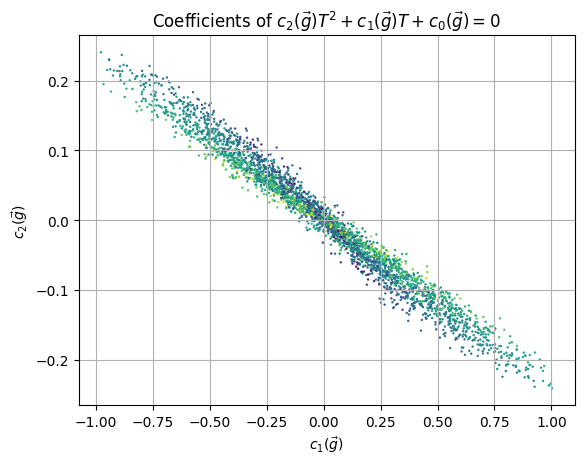

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

r = p.reduce(X_test[:,:-1]) #polynomials just in T

plt.scatter(r[:,1], r[:,2], c=X_test[:,-1], marker='o', s=(72./fig.dpi)**2)
plt.title(r'Coefficients of $c_2(\vec{g})T^2+c_1(\vec{g})T+c_0(\vec{g})=0$')
plt.xlabel(r'$c_1(\vec{g})$')
plt.ylabel(r'$c_2(\vec{g})$')
plt.grid(True)
plt.show()

Almost everywhere the implicit polynomial gives us up to two $T$ candidates. Are both physical?

But almost never the polynomial collapses to $0T^2+0T+c_0=0$.

At collapse, $T$ varies, so no easy continuation there.

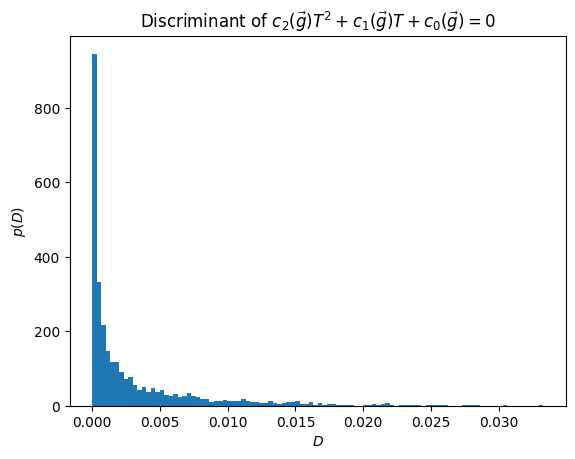

In [8]:
fig, ax = plt.subplots()

c, b, a = r.T
d = b**2 - 4*a*c
plt.hist(d, density=True, bins=100)
plt.title(r'Discriminant of $c_2(\vec{g})T^2+c_1(\vec{g})T+c_0(\vec{g})=0$')
plt.xlabel(r'$D$')
plt.ylabel(r'$p(D)$')
plt.show()

When the polynomial is used to solve for $T$, the discriminant is always non-negative -> no complex $T$ candidates.

- if both are physical: good,
- if one isn't: bad because filtering becomes more difficult.

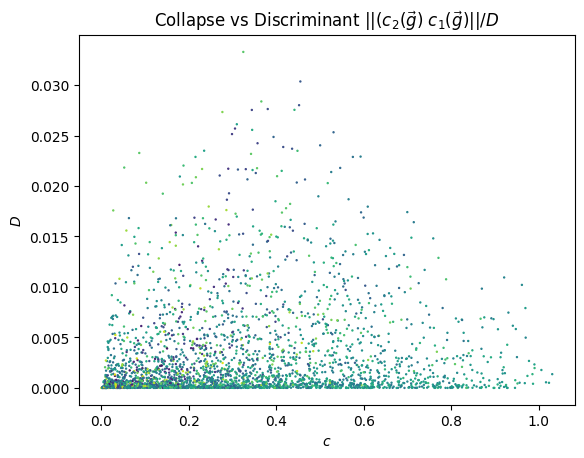

In [9]:
fig, ax = plt.subplots()

plt.scatter(np.linalg.norm(r[:,1:], axis=1), d, c=X_test[:,-1], marker='o', s=(72./fig.dpi)**2)
plt.title(r'Collapse vs Discriminant $||(c_2(\vec{g}) \ c_1(\vec{g})|| / D$')
plt.xlabel(r'$c$')
plt.ylabel(r'$D$')
plt.show()

No correlation between collapse & discriminant.

In [10]:
from cq.pythonic import rand_ortho_pair, vecabsq
from cq.symbolic import hermfkin, rho_to_g
from tqdm.auto import trange
from radicalfield import QuadraticElement235
from linalg import nullspace
from IPython.display import Latex

vtoqe235 = np.vectorize(QuadraticElement235.from_expr, [object])

D = 3
pows = np.array(list(sp.Poly(poly, *syms).as_dict().keys()), np.uint8)

n = pows.shape[0]
g, T = [], []
for _ in trange(n):
    v, w = rand_ortho_pair(D+1, grade=4)
    va, wa = vecabsq(v), vecabsq(w)
    
    T.append((hermfkin(v)/va + hermfkin(w)/wa).expand())
    rho = states_to_density(v)/va + states_to_density(w)/wa
    g.append(tuple(rho_to_g(rho).expand()))
g, T = np.array(g), np.array(T)

g, T = vtoqe235(g), vtoqe235(T)
X = np.column_stack([g[:,1:], T])

A = transform(X, pows)
k = dimker(A.astype(float))
assert k == 1

syms = sp.symbols(f'g1:{X.shape[1]} T')
K = nullspace(A, progress=True)
for c in K.T:
    tmp = ImplicitPolynomial(pows, c).to_sympy(*syms, trim=False)
    tmp = sp.Poly(tmp, syms[-1])
    display(tmp)
    print(sp.latex(tmp))

  0%|          | 0/54 [00:00<?, ?it/s]

neg:   0%|          | 0/729 [00:00<?, ?it/s]

sub:   0%|          | 0/154548 [00:00<?, ?it/s]

mul:   0%|          | 0/154548 [00:00<?, ?it/s]

truediv:   0%|          | 0/2916 [00:00<?, ?it/s]

bool:   0%|          | 0/54 [00:00<?, ?it/s]

gt:   0%|          | 0/2862 [00:00<?, ?it/s]

abs:   0%|          | 0/2916 [00:00<?, ?it/s]

Poly((-18*g1 + 24*sqrt(30)*g5/5)*T**2 + (-12*sqrt(2)*g1*g2 - 2*sqrt(6)*g1*g4 + 12*sqrt(5)*g1*g6 + 108*g1 + 19*sqrt(3)*g2*g3 - 54*sqrt(15)*g2*g5/5 - 6*g3*g4 - 17*sqrt(30)*g3*g6/5 - 28*sqrt(6)*g3 + 12*sqrt(5)*g4*g5 - 22*sqrt(6)*g5*g6/5 - 32*sqrt(30)*g5/5)*T + g1**3 - 17*sqrt(6)*g1**2*g3/12 + 7*sqrt(30)*g1**2*g5/15 + 41*g1*g2**2/4 - 49*sqrt(3)*g1*g2*g4/3 + 7*sqrt(10)*g1*g2*g6 + 51*sqrt(2)*g1*g2/2 + 7*g1*g3**2/2 - 11*sqrt(5)*g1*g3*g5/5 + 16*g1*g4**2 - 44*sqrt(30)*g1*g4*g6/15 + 11*sqrt(6)*g1*g4/3 + 8*g1*g5**2/5 - 8*g1*g6**2/5 - 138*sqrt(5)*g1*g6/5 - 275*g1/2 + 25*sqrt(6)*g2**2*g3/12 - 71*sqrt(30)*g2**2*g5/30 + 3*sqrt(2)*g2*g3*g4/2 - 9*sqrt(15)*g2*g3*g6/2 - 93*sqrt(3)*g2*g3/2 + 5*sqrt(10)*g2*g4*g5 + 83*sqrt(3)*g2*g5*g6/15 + 367*sqrt(15)*g2*g5/15 - 5*sqrt(6)*g3**3/12 + 2*sqrt(30)*g3**2*g5/5 - 2*sqrt(6)*g3*g4**2 + 26*sqrt(5)*g3*g4*g6/5 + 25*g3*g4 - 3*sqrt(6)*g3*g5**2/5 + 2*sqrt(6)*g3*g6**2/3 + 257*sqrt(30)*g3*g6/30 + 154*sqrt(6)*g3/3 - 4*sqrt(30)*g4**2*g5/5 - 36*g4*g5*g6/5 - 138*sqrt(5)*g4*g5/

\operatorname{Poly}{\left( \left(- 18 g_{1} + \frac{24 \sqrt{30} g_{5}}{5}\right) T^{2} + \left(- 12 \sqrt{2} g_{1} g_{2} - 2 \sqrt{6} g_{1} g_{4} + 12 \sqrt{5} g_{1} g_{6} + 108 g_{1} + 19 \sqrt{3} g_{2} g_{3} - \frac{54 \sqrt{15} g_{2} g_{5}}{5} - 6 g_{3} g_{4} - \frac{17 \sqrt{30} g_{3} g_{6}}{5} - 28 \sqrt{6} g_{3} + 12 \sqrt{5} g_{4} g_{5} - \frac{22 \sqrt{6} g_{5} g_{6}}{5} - \frac{32 \sqrt{30} g_{5}}{5}\right) T + g_{1}^{3} - \frac{17 \sqrt{6} g_{1}^{2} g_{3}}{12} + \frac{7 \sqrt{30} g_{1}^{2} g_{5}}{15} + \frac{41 g_{1} g_{2}^{2}}{4} - \frac{49 \sqrt{3} g_{1} g_{2} g_{4}}{3} + 7 \sqrt{10} g_{1} g_{2} g_{6} + \frac{51 \sqrt{2} g_{1} g_{2}}{2} + \frac{7 g_{1} g_{3}^{2}}{2} - \frac{11 \sqrt{5} g_{1} g_{3} g_{5}}{5} + 16 g_{1} g_{4}^{2} - \frac{44 \sqrt{30} g_{1} g_{4} g_{6}}{15} + \frac{11 \sqrt{6} g_{1} g_{4}}{3} + \frac{8 g_{1} g_{5}^{2}}{5} - \frac{8 g_{1} g_{6}^{2}}{5} - \frac{138 \sqrt{5} g_{1} g_{6}}{5} - \frac{275 g_{1}}{2} + \frac{25 \sqrt{6} g_{2}^{2} g_{3}}{12} - \frac{7

## 4 / 1

These are the pick 3 out of 4 Cramer pick rational solutions.

In [11]:
from cq.numeric import *

n = 10000

v, w = rand_ortho_pair(D+1, n)
T = hermfkin(v) + hermfkin(w)
rho = states_to_density(v, w)
g = rho_to_g(rho)

X = np.column_stack([g[:,1:], T]) #remove g_0 to avoid bias ruining implicit polynomial fit
X_train, X_test = train_test_split(X, test_size=0.3)

pows = powers(X.shape[1], 4, 1, False)
_, p = ImplicitPolynomial.fit(X_train, pows)
for poly in p:
    assert np.isclose(np.std(poly(X_test)), 0)
    poly = poly.to_sympy(*syms, trim=True)
    display(sp.Poly(poly, syms[-1]))

C:\Users\S.Goessl\AppData\Local\Temp\ipykernel_29684\3340393740.py:14: UserWarning: Kernel dimensionality 4; solution is not unique!
  _, p = ImplicitPolynomial.fit(X_train, pows)


Poly((-0.0221083114201559*g1**3 - 0.00919704318517862*g1**2*g2 + 0.039543742736867*g1**2*g3 + 0.0313700615067063*g1**2*g4 + 0.0209086156078593*g1**2*g5 - 0.0455763659947612*g1**2*g6 - 0.0127496856319923*g1**2 + 0.0143151505182464*g1*g2**2 - 0.0144995890380627*g1*g2*g3 - 0.0661188480416903*g1*g2*g4 + 0.0527597156882779*g1*g2*g5 + 0.0814832652345663*g1*g2*g6 + 0.020244680010482*g1*g2 - 0.0101790193216024*g1*g3**2 - 0.0383061452458898*g1*g3*g4 - 0.0748291462360929*g1*g3*g5 + 0.0998124121859289*g1*g3*g6 + 0.025990227484179*g1*g3 + 0.0572606020731463*g1*g4**2 - 0.0230626378738712*g1*g4*g5 - 0.114997385843266*g1*g4*g6 - 0.0233765429075876*g1*g4 + 0.0402076087720587*g1*g5**2 - 0.0454407517452765*g1*g5*g6 - 0.00924851674165995*g1*g5 + 0.0458084816585762*g1*g6**2 + 0.0128038598671429*g1*g6 + 0.000121102677822369*g2**3 - 0.00740099623931861*g2**2*g3 - 0.000699186636402092*g2**2*g4 - 0.00766931105393233*g2**2*g5 + 0.000765920585329417*g2**2*g6 + 0.00017126504940788*g2**2 + 0.0255133269742646*g2*g

Poly((-0.0105309680524608*g1**3 + 0.00355219718732795*g1**2*g2 + 0.0088732921400557*g1**2*g3 - 0.0140111711571197*g1**2*g4 + 0.0242170900080257*g1**2*g5 + 0.0213100477167867*g1**2*g6 + 0.00591902845335485*g1**2 + 0.0165803080930426*g1*g2**2 + 0.00761019906077559*g1*g2*g3 - 0.0765811627262092*g1*g2*g4 - 0.0241443084590285*g1*g2*g5 + 0.0943767681865713*g1*g2*g6 + 0.0234480965735634*g1*g2 + 0.00328595535850244*g1*g3**2 + 0.0175580935790975*g1*g3*g4 - 0.0327334438966406*g1*g3*g5 - 0.0474493880201263*g1*g3*g6 - 0.0122040233182044*g1*g3 + 0.0663212323723241*g1*g4**2 + 0.00969836168699694*g1*g4*g5 - 0.133193995043588*g1*g4*g6 - 0.0270755297376216*g1*g4 - 0.00167222616431947*g1*g5**2 + 0.0225319262256434*g1*g5*g6 + 0.00454063177789275*g1*g5 + 0.0530569858979499*g1*g6**2 + 0.0148298783938405*g1*g6 + 0.000422125313364283*g2**3 + 0.0283555612489385*g2**2*g3 - 0.00243714163306639*g2**2*g4 - 0.0749410600020505*g2**2*g5 + 0.00266975489652621*g2**2*g6 + 0.000596975343293239*g2**2 - 0.0119641226077949

Poly((0.0214697814463626*g1**3 - 0.01261017424687*g1**2*g2 - 0.0443343531901822*g1**2*g3 + 0.0306962382067663*g1**2*g4 - 0.0118145334765324*g1**2*g5 - 0.0383990625179071*g1**2*g6 - 0.0110168888652893*g1**2 - 0.00808885811436501*g1*g2**2 - 0.00681786689568494*g1*g2*g3 + 0.0373608352781327*g1*g2*g4 + 0.0478594904011603*g1*g2*g5 - 0.0460425875603959*g1*g2*g6 - 0.0114393728494923*g1*g2 + 0.0147290663510654*g1*g3**2 - 0.0345654645019683*g1*g3*g4 + 0.0744009936946137*g1*g3*g5 + 0.0790229782947298*g1*g3*g6 + 0.0215605097437205*g1*g3 - 0.0323554324574811*g1*g4**2 - 0.0264819921042461*g1*g4*g5 + 0.0649799341209208*g1*g4*g6 + 0.0132090499880696*g1*g4 - 0.0514470699843836*g1*g5**2 - 0.0299318561714557*g1*g5*g6 - 0.00638622009297939*g1*g5 - 0.0258843459659951*g1*g6**2 - 0.00723489464171282*g1*g6 + 0.0032133716151036*g2**3 + 0.0261719094567206*g2**2*g3 - 0.018552409669889*g2**2*g4 - 0.0350032014404247*g2**2*g5 + 0.0203231465445305*g2**2*g6 + 0.00454439371913174*g2**2 + 0.0212686547646133*g2*g3**2 -

Poly((0.00364871017666181*g1**3 + 0.0287264976674166*g1**2*g2 - 0.00789856436343256*g1**2*g3 - 0.0309845468231983*g1**2*g4 - 0.00148677239132566*g1**2*g5 + 0.0112967093954014*g1**2*g6 + 0.00465624132425617*g1**2 - 0.00101792342163052*g1*g2**2 - 0.0257736430640721*g1*g2*g3 + 0.00470158701618132*g1*g2*g4 - 0.0316187114355008*g1*g2*g5 - 0.00579412186339796*g1*g2*g6 - 0.0014395613354347*g1*g2 + 0.002800440625628*g1*g3**2 + 0.0219618709104948*g1*g3*g4 + 0.0127505362221591*g1*g3*g5 + 0.00284753489510776*g1*g3*g6 - 0.00460972993021034*g1*g3 - 0.00407169389727459*g1*g4**2 + 0.0440757775645766*g1*g4*g5 + 0.00817724824673152*g1*g4*g6 + 0.00166226243100825*g1*g4 - 0.00950430248883852*g1*g5**2 - 0.0341777993080921*g1*g5*g6 - 0.00535561591466468*g1*g5 - 0.0032573552233774*g1*g6**2 - 0.000910458832620628*g1*g6 - 0.0169560252369138*g2**3 + 0.00561295404201727*g2**2*g3 + 0.0978956573499409*g2**2*g4 - 0.00855398511756124*g2**2*g5 - 0.107239319624328*g2**2*g6 - 0.0239794408567522*g2**2 - 0.0050896298235

## 4/3 -> 4/4

In [12]:
pows = powers(X.shape[1], 4, 3, False)
_, p = ImplicitPolynomial.fit(X_train, pows)
A = np.column_stack([pi.coefs for pi in p])
pows[-5:]

C:\Users\S.Goessl\AppData\Local\Temp\ipykernel_29684\4258981821.py:2: UserWarning: Kernel dimensionality 26; solution is not unique!
  _, p = ImplicitPolynomial.fit(X_train, pows)


array([[0, 0, 0, 0, 1, 0, 3],
       [0, 0, 0, 0, 0, 4, 0],
       [0, 0, 0, 0, 0, 3, 1],
       [0, 0, 0, 0, 0, 2, 2],
       [0, 0, 0, 0, 0, 1, 3]], dtype=uint8)

In [13]:
pows = powers(X.shape[1], 4, 4, True)
_, p = ImplicitPolynomial.fit(X_train, pows)
B = np.column_stack([pi.coefs for pi in p])
pows[-5:]

C:\Users\S.Goessl\AppData\Local\Temp\ipykernel_29684\1612624751.py:2: UserWarning: Kernel dimensionality 27; solution is not unique!
  _, p = ImplicitPolynomial.fit(X_train, pows)


array([[0, 0, 0, 0, 0, 4, 0],
       [0, 0, 0, 0, 0, 3, 1],
       [0, 0, 0, 0, 0, 2, 2],
       [0, 0, 0, 0, 0, 1, 3],
       [0, 0, 0, 0, 0, 0, 4]], dtype=uint8)

In [14]:
A = np.insert(A, -1, 0, axis=0)
A.shape, B.shape

((330, 26), (330, 27))

In [15]:
def span_difference(A, B):
    # Orthonormal bases for span(A) and span(B)
    QA, _ = np.linalg.qr(A.T)   # (100, 26)
    QB, _ = np.linalg.qr(B.T)   # (100, 27)
    
    # Remove from span(B) everything lying in span(A)
    R = QB - QA @ (QA.T @ QB)
    
    # R should have rank 1 if span(A) ⊂ span(B)
    U, S, _ = np.linalg.svd(R, full_matrices=False)
    
    #print("residual singular values:", S)
    
    # Unique additional direction
    return U[:, 0]

c = span_difference(A.T, B.T)

In [16]:
print(np.linalg.norm(A.T @ c))   # should be ~0
print(np.linalg.matrix_rank(np.vstack([A.T, c])))  # should be 27

3.856408705614211e-16
27


In [17]:
c /= c[-1]
poly = ImplicitPolynomial(pows, c).to_sympy(*syms, trim=True)
poly = sp.Poly(poly, syms[-1])
print(sp.latex(poly))
poly

\operatorname{Poly}{\left( 1.0 T^{4} + \left(- 0.106707368180502 g_{2} + 0.629741546340875 g_{4} - 1.645914758193 g_{6} - 6.95199261038462\right) T^{3} + \left(- 0.174632781451685 g_{1}^{2} + 0.647255901720217 g_{1} g_{3} - 0.194140539004505 g_{1} g_{5} + 0.689764985032268 g_{2}^{2} - 1.42979143240627 g_{2} g_{4} + 1.57953156415135 g_{2} g_{6} - 1.74002682506469 g_{2} - 0.539467827876085 g_{3}^{2} + 0.62580802734051 g_{3} g_{5} + 0.343481782814396 g_{4}^{2} - 0.844480553576552 g_{4} g_{6} + 0.81053753530422 g_{4} - 0.139569250957209 g_{5}^{2} + 1.03408636693801 g_{6}^{2} + 2.68662175427224 g_{6} + 18.1783600403396\right) T^{2} + \left(- 0.090563941676821 g_{1}^{2} g_{2} + 0.0370450012097557 g_{1}^{2} g_{4} + 0.744591659482968 g_{1}^{2} g_{6} - 0.763678877503108 g_{1}^{2} + 0.0585541684796928 g_{1} g_{2} g_{3} - 0.316899935265299 g_{1} g_{2} g_{5} + 0.18881238635001 g_{1} g_{3} g_{4} - 1.75183844297293 g_{1} g_{3} g_{6} + 0.154793932262751 g_{1} g_{3} + 0.266273892868836 g_{1} g_{4} g_{

Poly(1.0*T**4 + (-0.106707368180502*g2 + 0.629741546340875*g4 - 1.645914758193*g6 - 6.95199261038462)*T**3 + (-0.174632781451685*g1**2 + 0.647255901720217*g1*g3 - 0.194140539004505*g1*g5 + 0.689764985032268*g2**2 - 1.42979143240627*g2*g4 + 1.57953156415135*g2*g6 - 1.74002682506469*g2 - 0.539467827876085*g3**2 + 0.62580802734051*g3*g5 + 0.343481782814396*g4**2 - 0.844480553576552*g4*g6 + 0.81053753530422*g4 - 0.139569250957209*g5**2 + 1.03408636693801*g6**2 + 2.68662175427224*g6 + 18.1783600403396)*T**2 + (-0.090563941676821*g1**2*g2 + 0.0370450012097557*g1**2*g4 + 0.744591659482968*g1**2*g6 - 0.763678877503108*g1**2 + 0.0585541684796928*g1*g2*g3 - 0.316899935265299*g1*g2*g5 + 0.18881238635001*g1*g3*g4 - 1.75183844297293*g1*g3*g6 + 0.154793932262751*g1*g3 + 0.266273892868836*g1*g4*g5 + 0.525536942947644*g1*g5*g6 - 0.358551952704496*g1*g5 - 0.238845631879525*g2**3 + 0.280352367384591*g2**2*g4 - 0.39677793295306*g2**2*g6 - 0.205269419361566*g2**2 - 0.415141269597575*g2*g3**2 + 1.266109472

## 5/2 -> 5/3

In [18]:
pows = powers(X.shape[1], 5, 2, False)
_, p = ImplicitPolynomial.fit(X_train, pows)
A = np.column_stack([pi.coefs for pi in p])

pows = powers(X.shape[1], 5, 3, True)
_, p = ImplicitPolynomial.fit(X_train, pows)
B = np.column_stack([pi.coefs for pi in p])

def find_indices(sequence, predicate) -> list[int]:
    return [i for i, e in enumerate(sequence) if predicate(e)]

def find_index(sequence, predicate) -> int:
    indices = find_indices(sequence, predicate)
    if len(indices) == 0:
        raise ValueError('no elements found')
    elif len(indices) > 1:
        raise ValueError('multiple elements found')
    return indices[0]

A = np.insert(A, find_index(pows, lambda e: tuple(map(int, e))==(0, 0, 0, 0, 0, 0, 3)), 0, axis=0)

C:\Users\S.Goessl\AppData\Local\Temp\ipykernel_29684\1972843152.py:2: UserWarning: Kernel dimensionality 117; solution is not unique!
  _, p = ImplicitPolynomial.fit(X_train, pows)
C:\Users\S.Goessl\AppData\Local\Temp\ipykernel_29684\1972843152.py:6: UserWarning: Kernel dimensionality 118; solution is not unique!
  _, p = ImplicitPolynomial.fit(X_train, pows)


In [19]:
c = span_difference(A.T, B.T)

print(np.linalg.norm(A.T @ c))   # should be ~0
print(np.linalg.matrix_rank(np.vstack([A.T, c])))  # should be 118

6.20943740116631e-16
118


In [20]:
c /= c[find_index(pows, lambda e: tuple(map(int, e))==(0, 0, 0, 0, 0, 0, 3))]
poly = ImplicitPolynomial(pows, c).to_sympy(*syms, trim=True)
poly = sp.Poly(poly, syms[-1])
print(sp.latex(poly))
poly

\operatorname{Poly}{\left( 1.0 T^{3} + \left(0.00820386275926463 g_{1}^{2} g_{2} + 0.080051268643822 g_{1}^{2} g_{4} - 0.16069517371298 g_{1}^{2} g_{6} + 0.0690613060525224 g_{1}^{2} - 0.0381703104207746 g_{1} g_{2} g_{3} + 0.0996444136249371 g_{1} g_{2} g_{5} - 0.0748720899961234 g_{1} g_{3} g_{4} + 0.30947618057138 g_{1} g_{3} g_{6} - 0.21819729827135 g_{1} g_{3} + 0.0222583971791465 g_{1} g_{4} g_{5} - 0.227843506854142 g_{1} g_{5} g_{6} + 0.00724562168511799 g_{1} g_{5} + 0.0864823467628957 g_{2}^{3} - 0.222205351220082 g_{2}^{2} g_{4} + 0.312811900966812 g_{2}^{2} g_{6} - 0.337774927952783 g_{2}^{2} + 0.107995331111263 g_{2} g_{3}^{2} - 0.426281748421653 g_{2} g_{3} g_{5} + 0.162615504056177 g_{2} g_{4}^{2} - 0.698812125547307 g_{2} g_{4} g_{6} + 0.954647618654152 g_{2} g_{4} + 0.247953636431785 g_{2} g_{5}^{2} + 0.340322502027302 g_{2} g_{6}^{2} - 0.181579290989088 g_{2} g_{6} - 0.00197414291462645 g_{2} + 0.0760502544965962 g_{3}^{2} g_{4} - 0.304689553533335 g_{3}^{2} g_{6} + 0

Poly(1.0*T**3 + (0.00820386275926463*g1**2*g2 + 0.080051268643822*g1**2*g4 - 0.16069517371298*g1**2*g6 + 0.0690613060525224*g1**2 - 0.0381703104207746*g1*g2*g3 + 0.0996444136249371*g1*g2*g5 - 0.0748720899961234*g1*g3*g4 + 0.30947618057138*g1*g3*g6 - 0.21819729827135*g1*g3 + 0.0222583971791465*g1*g4*g5 - 0.227843506854142*g1*g5*g6 + 0.00724562168511799*g1*g5 + 0.0864823467628957*g2**3 - 0.222205351220082*g2**2*g4 + 0.312811900966812*g2**2*g6 - 0.337774927952783*g2**2 + 0.107995331111263*g2*g3**2 - 0.426281748421653*g2*g3*g5 + 0.162615504056177*g2*g4**2 - 0.698812125547307*g2*g4*g6 + 0.954647618654152*g2*g4 + 0.247953636431785*g2*g5**2 + 0.340322502027302*g2*g6**2 - 0.181579290989088*g2*g6 - 0.00197414291462645*g2 + 0.0760502544965962*g3**2*g4 - 0.304689553533335*g3**2*g6 + 0.0606171638562588*g3**2 + 0.158968426612624*g3*g4*g5 + 0.151567873989889*g3*g5*g6 + 0.0471347385226397*g3*g5 - 0.0844311234706127*g4**3 + 0.692718665013587*g4**2*g6 - 0.457111763301875*g4**2 - 0.254882716601344*g4*g5

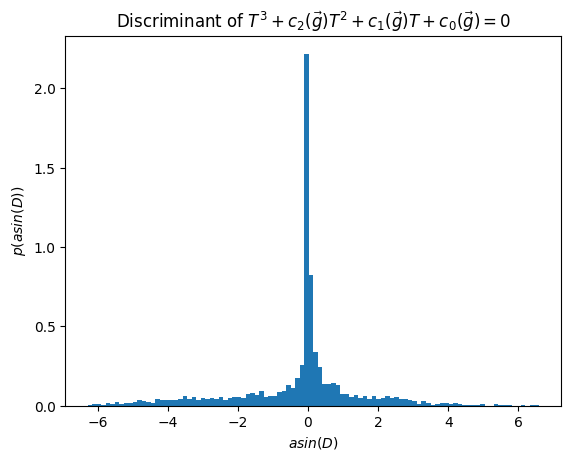

In [21]:
fig, ax = plt.subplots()

r = ImplicitPolynomial(pows, c).reduce(X_test[:,:-1]) #polynomials just in T
d, c, b, a = r.T
d = (4*(b**2-3*a*c)**3 - (2*b**3-9*a*b*c+27*a**2*d)**2) / (27*a**2)
plt.hist(np.asinh(d), density=True, bins=100)
plt.title(r'Discriminant of $T^3+c_2(\vec{g})T^2+c_1(\vec{g})T+c_0(\vec{g})=0$')
plt.xlabel(r'$asin(D)$')
plt.ylabel(r'$p(asin(D))$')
plt.show()

[Wikipedia - Cubic equation - Nature of the roots](https://en.wikipedia.org/wiki/Cubic_equation#Nature_of_the_roots)

- $\Delta>0$: three distinct real roots (problematic)
- $\Delta<0$: one real root & two non-real complex roots (easy)
- $\Delta=0$: one real root with multiplicity 3 (easy)

In [22]:
for i in range(10):
    print('Discriminant:', d[i])
    display(sp.Poly.from_list(list(reversed(r[i])), syms[-1]))
    print('Solutions:', np.polynomial.polynomial.polyroots(r[i]))
    print('T:', X_test[i,-1])
    print()

Discriminant: 0.08646802978798375


Poly(1.0*T**3 - 4.27589020402111*T**2 + 5.57408080673857*T - 2.28674347555049, T, domain='RR')

Solutions: [0.9160834  1.10906378 2.25074302]
T: 0.9160834008031726

Discriminant: -0.736905749884995


Poly(1.0*T**3 - 8.2151602855735*T**2 + 22.8522827502472*T - 21.365809243844, T, domain='RR')

Solutions: [2.42313746+0.j         2.89601142-0.65615027j 2.89601142+0.65615027j]
T: 2.423137455193415

Discriminant: 27.308991815368827


...

Solutions: [0.83939339 1.70832791 2.76120216]
T: 1.708327909578972

Discriminant: -0.07202461857655948


Poly(1.0*T**3 - 5.12664921751792*T**2 + 8.56963331996211*T - 4.72451711868789, T, domain='RR')

Solutions: [1.43413084-0.18776481j 1.43413084+0.18776481j 2.25838754+0.j        ]
T: 2.2583875421666075

Discriminant: 1.6935600923199754


Poly(1.0*T**3 - 5.6073856289714*T**2 + 9.41446182024935*T - 4.19470125324259, T, domain='RR')

Solutions: [0.70304186 2.23619946 2.66814431]
T: 2.236199458774107

